In [20]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as pltr

In [21]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [22]:
print("Missing Values:\n")

print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [23]:
X = df.drop("Reached.on.Time_Y.N", axis=1)

y = df["Reached.on.Time_Y.N"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10999, 11)
Target Shape: (10999,)


In [24]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape:", X.shape)

X.head()

Encoded Feature Shape: (10999, 16)


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,4,2,177,3,44,1233,False,False,True,False,False,False,True,False,False
1,2,4,5,216,2,59,3088,False,False,False,True,False,False,True,False,True
2,3,2,2,183,4,48,3374,False,False,False,False,False,False,True,False,True
3,4,3,3,176,4,10,1177,True,False,False,False,False,False,False,True,True
4,5,2,2,184,3,46,2484,False,True,False,False,False,False,False,True,False


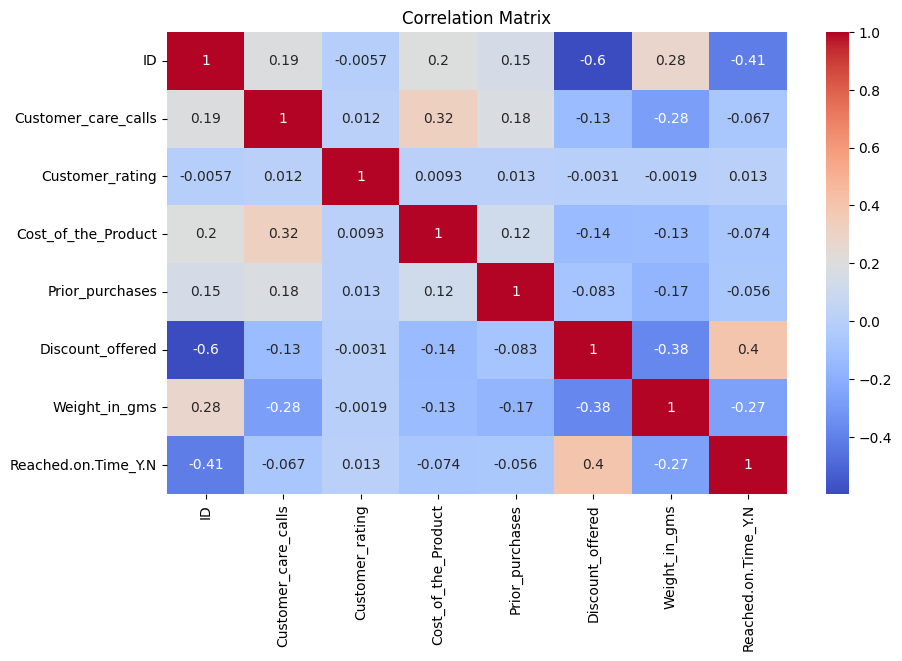

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [26]:
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")

print(selected_features)

Selected Features:
Index(['ID', 'Customer_care_calls', 'Cost_of_the_Product', 'Discount_offered',
       'Weight_in_gms'],
      dtype='object')


In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (10999, 5)


In [28]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)

print("PCA Shape:", X_pca.shape)

Original Shape: (10999, 5)
PCA Shape: (10999, 2)


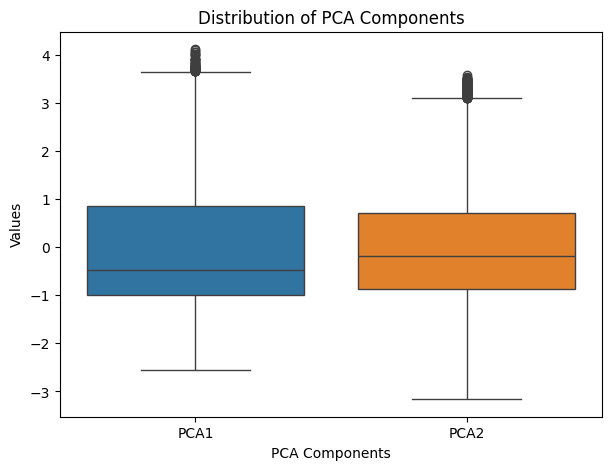

In [29]:
pca_df = pd.DataFrame(X_pca, columns=["PCA1","PCA2"])

plt.figure(figsize=(7,5))

sns.boxplot(data=pca_df)

plt.title("Distribution of PCA Components")

plt.xlabel("PCA Components")

plt.ylabel("Values")

plt.show()

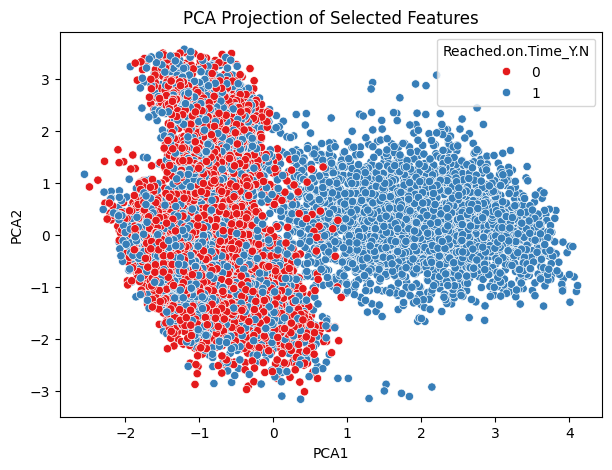

In [30]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=pca_df["PCA1"],
    y=pca_df["PCA2"],
    hue=y,
    palette="Set1"
)

plt.title("PCA Projection of Selected Features")

plt.show()